Multi-Layer Perceptron (MLP)

In Week 1 we built a **Random Forest** that reached **83.27%** accuracy. Now we build a **neural network** (MLP) to see if it can do better.

## What is an MLP?

A **Multi-Layer Perceptron** is the simplest type of neural network. It works like this:

1. **Input layer**: Takes in 784 numbers (our 28×28 flattened image).
2. **Hidden layers**: One or more layers of "neurons" that learn patterns. Each neuron takes all inputs, multiplies them by learned **weights**, adds a **bias**, and passes the result through an **activation function**.
3. **Output layer**: 24 neurons (one per letter). The highest value = the prediction.

### Key concepts in this notebook

| Concept | What it means |
|---------|---------------|
| **Epoch** | One full pass through all training data. We train for many epochs. |
| **Batch** | A small chunk of data (e.g. 64 images) processed at once. Faster than one-at-a-time. |
| **Loss** | A number measuring how wrong the model is. Lower = better. We use CrossEntropyLoss. |
| **Optimizer** | Algorithm that adjusts weights to reduce loss. We use Adam. |
| **Learning rate** | How big the weight adjustments are. Too high = unstable. Too low = slow. |
| **Activation function** | A math function applied after each layer. Introduces non-linearity so the network can learn complex patterns. |
| **ReLU** | Most common activation: if input > 0, keep it; if < 0, output 0. Simple and effective. |
| **Softmax** | Used at the output: converts raw numbers into probabilities that sum to 1. |

## To do

1. Load the same data as Week 1.
2. Build a configurable MLP in **PyTorch**.
3. Train it and log metrics to **Weights & Biases** (W&B) using wandb.ai and its API key.
4. Run **multiple experiments** with different architectures.
5. Compare all experiments + the Random Forest baseline on a W&B dashboard.


---
## 1. Install and import libraries

PyTorch is pre-installed on Kaggle. We only need to install **wandb** (Weights & Biases) for experiment tracking.

In [1]:
!pip install -q wandb

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import wandb

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

# Use GPU if available (you should have turned it on in Kaggle settings)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: No GPU detected. Training will be slower. Turn on GPU in Kaggle Settings.")

Using device: cuda
GPU: Tesla T4


---
## 2. Load data (same as Week 1)

Same pipeline: find CSVs, load, normalize to [0,1], filter labels 0–23.

In [3]:
# --- Find dataset (same logic as Week 1) ---
INPUT_DIR = Path("/kaggle/input")

def find_csv(root, name):
    for path in root.rglob(name):
        return path
    return None

train_path = find_csv(INPUT_DIR, "sign_mnist_train.csv")
test_path = find_csv(INPUT_DIR, "sign_mnist_test.csv")
assert train_path and test_path, "Dataset not found. Add Sign Language MNIST to this notebook."
print(f"Train: {train_path}")
print(f"Test:  {test_path}")

# --- Load and preprocess ---
LABELS = [
    "A", "B", "C", "D", "E", "F", "G", "H", "I",
    "K", "L", "M", "N", "O", "P", "Q", "R", "S",
    "T", "U", "V", "W", "X", "Y",
]
NUM_CLASSES = 24

def load_csv(path):
    df = pd.read_csv(path)
    y = df["label"].values.astype(np.int64)
    pixel_cols = [c for c in df.columns if c.startswith("pixel")]
    X = df[pixel_cols].values.astype(np.float32) / 255.0
    return X, y

X_train, y_train = load_csv(train_path)
X_test, y_test = load_csv(test_path)

# Filter to labels 0–23 (same as Week 1)
mask_train = (y_train >= 0) & (y_train < NUM_CLASSES)
mask_test = (y_test >= 0) & (y_test < NUM_CLASSES)
X_train, y_train = X_train[mask_train], y_train[mask_train]
X_test, y_test = X_test[mask_test], y_test[mask_test]

print(f"Train: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test:  {X_test.shape[0]} samples")
print(f"Labels: {y_train.min()} to {y_train.max()}")

Train: /kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_train.csv
Test:  /kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_test.csv
Train: 26337 samples, 784 features
Test:  6840 samples
Labels: 0 to 23


---
## 3. Create PyTorch DataLoaders

PyTorch needs data in a special format:
- **Tensor**: PyTorch's version of a numpy array (can run on GPU).
- **TensorDataset**: Pairs X and y tensors together.
- **DataLoader**: Feeds data to the model in **batches** (e.g. 64 images at a time). This is faster than feeding one image at a time.

In [6]:
BATCH_SIZE = 64

# Convert numpy arrays to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)} (batch size={BATCH_SIZE})")
print(f"Test batches:  {len(test_loader)}")

Train batches: 412 (batch size=64)
Test batches:  107


---
## 4. Define the MLP model

This is the neural network itself. We make it **configurable** so we can easily try different architectures:
- Different numbers of hidden layers.
- Different numbers of neurons per layer.
- Different activation functions.

### How it works (step by step)

```
Input (784 pixels)
  → Linear layer (784 → hidden_size)   # multiply by weights, add bias
  → Activation (e.g. ReLU)             # introduce non-linearity
  → Linear layer (hidden_size → hidden_size)  # another layer
  → Activation
  → ... (repeat for each hidden layer)
  → Linear layer (last_hidden → 24)    # output: one score per letter
```

The model learns the weights and biases during training.

In [7]:
class SignLanguageMLP(nn.Module):
    """
    Configurable Multi-Layer Perceptron for sign language classification.
    
    Args:
        hidden_sizes: List of integers, one per hidden layer.
                      e.g. [256, 128] = two hidden layers with 256 and 128 neurons.
        activation:   Which activation function to use ('relu', 'tanh', 'leaky_relu').
        dropout:      Fraction of neurons to randomly "turn off" during training (prevents overfitting).
    """
    def __init__(self, hidden_sizes, activation="relu", dropout=0.0):
        super().__init__()
        
        # Choose activation function
        activations = {
            "relu": nn.ReLU(),
            "tanh": nn.Tanh(),
            "leaky_relu": nn.LeakyReLU(0.1),
        }
        act_fn = activations.get(activation, nn.ReLU())
        
        # Build layers dynamically
        layers = []
        input_size = 784  # 28×28 flattened
        
        for h_size in hidden_sizes:
            layers.append(nn.Linear(input_size, h_size))  # weights + bias
            layers.append(act_fn)                          # activation
            if dropout > 0:
                layers.append(nn.Dropout(dropout))         # dropout (regularization)
            input_size = h_size  # next layer's input = this layer's output
        
        layers.append(nn.Linear(input_size, NUM_CLASSES))  # final: hidden → 24 classes
        
        # nn.Sequential chains all layers together
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        """Pass input through all layers and return raw scores (logits)."""
        return self.network(x)


# Quick test: create a small model and pass a fake batch through it
test_model = SignLanguageMLP(hidden_sizes=[128, 64], activation="relu")
fake_input = torch.randn(4, 784)  # 4 fake images
fake_output = test_model(fake_input)
print(f"Test model output shape: {fake_output.shape} (should be [4, 24])")
print(f"Model architecture:\n{test_model}")

Test model output shape: torch.Size([4, 24]) (should be [4, 24])
Model architecture:
SignLanguageMLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=24, bias=True)
  )
)


---
## 5. Training function

This is the **training loop** — the heart of neural network training. Here's what happens each epoch:

1. **Forward pass**: Feed a batch of images through the network → get predictions.
2. **Compute loss**: Compare predictions to true labels using CrossEntropyLoss.
3. **Backward pass** (backpropagation): Calculate how much each weight contributed to the error.
4. **Update weights**: The optimizer adjusts weights to reduce the loss.
5. **Repeat** for all batches in the training set = 1 epoch.

After each epoch, we evaluate on the test set (without updating weights) to see how well the model generalizes.

### What is Weights & Biases (W&B)?

W&B is a free tool that **logs your experiments automatically**. Every time you train a model, it records:
- Loss and accuracy over time (creates charts).
- The hyperparameters you used.
- System metrics (GPU usage, etc.).

You get a **dashboard** where you can compare all your experiments side by side. This is a deliverable.

In [8]:
def train_and_evaluate(model, train_loader, test_loader, config, device):
    """
    Train the model and log everything to W&B.
    
    Args:
        model: The MLP model.
        train_loader: DataLoader for training data.
        test_loader: DataLoader for test data.
        config: Dict with 'epochs', 'lr' (learning rate), and experiment name.
        device: 'cuda' or 'cpu'.
    
    Returns:
        Dict with final test accuracy and best test accuracy.
    """
    model = model.to(device)
    
    # Loss function: CrossEntropyLoss
    # Combines softmax + negative log likelihood.
    # It measures how far the predicted probabilities are from the true label.
    criterion = nn.CrossEntropyLoss()
    
    # Optimizer: Adam
    # A smart optimizer that adapts the learning rate for each weight.
    # lr = learning rate: how big the steps are when adjusting weights.
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])
    
    best_test_acc = 0.0
    
    for epoch in range(config["epochs"]):
        # --- Training phase ---
        model.train()  # tell PyTorch we're training (enables dropout, etc.)
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()          # reset gradients from last batch
            outputs = model(X_batch)       # forward pass: input → predictions
            loss = criterion(outputs, y_batch)  # how wrong are we?
            loss.backward()                # backward pass: compute gradients
            optimizer.step()               # update weights
            
            train_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)  # class with highest score
            train_correct += (predicted == y_batch).sum().item()
            train_total += y_batch.size(0)
        
        train_loss /= train_total
        train_acc = train_correct / train_total
        
        # --- Evaluation phase ---
        model.eval()  # tell PyTorch we're evaluating (disables dropout)
        test_loss = 0.0
        test_correct = 0
        test_total = 0
        
        with torch.no_grad():  # no need to track gradients during evaluation
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                
                test_loss += loss.item() * X_batch.size(0)
                _, predicted = torch.max(outputs, 1)
                test_correct += (predicted == y_batch).sum().item()
                test_total += y_batch.size(0)
        
        test_loss /= test_total
        test_acc = test_correct / test_total
        best_test_acc = max(best_test_acc, test_acc)
        
        # --- Log to W&B ---
        wandb.log({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "test_loss": test_loss,
            "test_accuracy": test_acc,
        })
        
        # Print every 5 epochs (less clutter)
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{config['epochs']}  "
                  f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}  |  "
                  f"Test Loss: {test_loss:.4f}  Acc: {test_acc:.4f}")
    
    return {"final_test_acc": test_acc, "best_test_acc": best_test_acc}

print("Training function defined.")

Training function defined.


---
## 6. Log in to Weights & Biases

You need a **free W&B account**:
1. Go to [wandb.ai](https://wandb.ai) and sign up (use Google/GitHub).
2. Go to [wandb.ai/authorize](https://wandb.ai/authorize) to get your **API key**.
3. Paste the key when prompted below.

This only needs to be done once per Kaggle session.

In [9]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: codeofficialsian (codeofficialsian-university-of-louisiana-monroe) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

---
## 7. Run experiments with different architectures

We'll train **5 different MLP configurations** and compare them. Each experiment varies one thing:

| # | Name | Hidden layers | Activation | Why we're testing this |
|---|------|--------------|------------|------------------------|
| 1 | Small (1 layer) | [128] | ReLU | Simplest possible MLP — how far can 1 layer go? |
| 2 | Medium (2 layers) | [256, 128] | ReLU | Adding depth — does a second layer help? |
| 3 | Large (3 layers) | [512, 256, 128] | ReLU | Even deeper — is more always better? |
| 4 | Medium + Tanh | [256, 128] | Tanh | Same shape, different activation — does it matter? |
| 5 | Medium + Dropout | [256, 128] | ReLU + 30% dropout | Regularization — does preventing overfitting help? |

All use the same learning rate (0.001) and 30 epochs so the comparison is fair.

In [10]:
experiments = [
    {
        "name": "MLP-1layer-128-relu",
        "hidden_sizes": [128],
        "activation": "relu",
        "dropout": 0.0,
        "lr": 0.001,
        "epochs": 30,
    },
    {
        "name": "MLP-2layer-256-128-relu",
        "hidden_sizes": [256, 128],
        "activation": "relu",
        "dropout": 0.0,
        "lr": 0.001,
        "epochs": 30,
    },
    {
        "name": "MLP-3layer-512-256-128-relu",
        "hidden_sizes": [512, 256, 128],
        "activation": "relu",
        "dropout": 0.0,
        "lr": 0.001,
        "epochs": 30,
    },
    {
        "name": "MLP-2layer-256-128-tanh",
        "hidden_sizes": [256, 128],
        "activation": "tanh",
        "dropout": 0.0,
        "lr": 0.001,
        "epochs": 30,
    },
    {
        "name": "MLP-2layer-256-128-relu-dropout30",
        "hidden_sizes": [256, 128],
        "activation": "relu",
        "dropout": 0.3,
        "lr": 0.001,
        "epochs": 30,
    },
]

all_results = []

for i, exp in enumerate(experiments):
    print(f"\n{'='*60}")
    print(f"Experiment {i+1}/{len(experiments)}: {exp['name']}")
    print(f"  Hidden layers: {exp['hidden_sizes']}")
    print(f"  Activation: {exp['activation']}, Dropout: {exp['dropout']}")
    print(f"  LR: {exp['lr']}, Epochs: {exp['epochs']}")
    print(f"{'='*60}")
    
    # Start a new W&B run for this experiment
    run = wandb.init(
        project="sign-language-mnist",
        name=exp["name"],
        config={
            "model_type": "MLP",
            "hidden_sizes": exp["hidden_sizes"],
            "activation": exp["activation"],
            "dropout": exp["dropout"],
            "learning_rate": exp["lr"],
            "epochs": exp["epochs"],
            "batch_size": BATCH_SIZE,
            "optimizer": "Adam",
        },
        reinit=True,
    )
    
    # Create model
    torch.manual_seed(RANDOM_SEED)
    model = SignLanguageMLP(
        hidden_sizes=exp["hidden_sizes"],
        activation=exp["activation"],
        dropout=exp["dropout"],
    )
    
    # Train
    start = time.time()
    result = train_and_evaluate(model, train_loader, test_loader, exp, device)
    elapsed = time.time() - start
    
    # Log final summary to W&B
    wandb.summary["best_test_accuracy"] = result["best_test_acc"]
    wandb.summary["training_time_seconds"] = elapsed
    wandb.finish()
    
    result["name"] = exp["name"]
    result["time"] = elapsed
    result["model"] = model
    all_results.append(result)
    
    print(f"  → Best test accuracy: {result['best_test_acc']*100:.2f}% ({elapsed:.1f}s)")

print(f"\n{'='*60}")
print("ALL EXPERIMENTS DONE")
print(f"{'='*60}")
for r in all_results:
    print(f"  {r['best_test_acc']*100:5.2f}%  ({r['time']:5.1f}s)  {r['name']}")

best_mlp = max(all_results, key=lambda r: r["best_test_acc"])
print(f"\nBest MLP: {best_mlp['name']} with {best_mlp['best_test_acc']*100:.2f}% accuracy")


Experiment 1/5: MLP-1layer-128-relu
  Hidden layers: [128]
  Activation: relu, Dropout: 0.0
  LR: 0.001, Epochs: 30


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


  Epoch   1/30  Train Loss: 2.2681  Acc: 0.3416  |  Test Loss: 1.6942  Acc: 0.4864
  Epoch   5/30  Train Loss: 0.7420  Acc: 0.7837  |  Test Loss: 1.0249  Acc: 0.6864
  Epoch  10/30  Train Loss: 0.3685  Acc: 0.9031  |  Test Loss: 0.9596  Acc: 0.6898
  Epoch  15/30  Train Loss: 0.1801  Acc: 0.9642  |  Test Loss: 1.0484  Acc: 0.7127
  Epoch  20/30  Train Loss: 0.0881  Acc: 0.9908  |  Test Loss: 1.2138  Acc: 0.7108
  Epoch  25/30  Train Loss: 0.0471  Acc: 0.9959  |  Test Loss: 1.2773  Acc: 0.7029
  Epoch  30/30  Train Loss: 0.0248  Acc: 0.9988  |  Test Loss: 1.3529  Acc: 0.7216


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test_accuracy,▁▃▅▅▇▇▆▆█▇██▇██████▇███▇▇█████
test_loss,█▅▃▃▂▂▂▂▁▁▁▂▂▂▂▂▂▂▂▄▃▄▃▅▄▄▄▅▅▅
train_accuracy,▁▄▅▅▆▆▆▇▇▇▇▇▇█████████████████
train_loss,█▅▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_test_accuracy,0.73012
epoch,30
test_accuracy,0.72164
test_loss,1.35289
train_accuracy,0.99878
train_loss,0.02478


  → Best test accuracy: 73.01% (31.1s)

Experiment 2/5: MLP-2layer-256-128-relu
  Hidden layers: [256, 128]
  Activation: relu, Dropout: 0.0
  LR: 0.001, Epochs: 30


...

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test_accuracy,▁▄▅▅▆▇▇▇▇▆▇▇▇▇▇█▇▇▇▇▇▆▇▇█▅████
test_loss,█▄▂▃▃▁▂▁▂▂▁▂▂▁▂▂▂▃▃▃▄▂▂▂▂▅▂▃▃▃
train_accuracy,▁▅▆▇█████████▇███████▇████████
train_loss,█▄▃▂▂▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁
best_test_accuracy,0.825
epoch,30
test_accuracy,0.81404
test_loss,0.88344
train_accuracy,1
train_loss,0.00326


  → Best test accuracy: 82.50% (28.9s)

Experiment 5/5: MLP-2layer-256-128-relu-dropout30
  Hidden layers: [256, 128]
  Activation: relu, Dropout: 0.3
  LR: 0.001, Epochs: 30


  Epoch   1/30  Train Loss: 2.4870  Acc: 0.2111  |  Test Loss: 1.7799  Acc: 0.4355
  Epoch   5/30  Train Loss: 0.9855  Acc: 0.6465  |  Test Loss: 1.0414  Acc: 0.6480
  Epoch  10/30  Train Loss: 0.6429  Acc: 0.7703  |  Test Loss: 0.7962  Acc: 0.7513
  Epoch  15/30  Train Loss: 0.5032  Acc: 0.8217  |  Test Loss: 0.7557  Acc: 0.7982
  Epoch  20/30  Train Loss: 0.4271  Acc: 0.8493  |  Test Loss: 0.8533  Acc: 0.7670
  Epoch  25/30  Train Loss: 0.3671  Acc: 0.8723  |  Test Loss: 0.8255  Acc: 0.7839
  Epoch  30/30  Train Loss: 0.3242  Acc: 0.8867  |  Test Loss: 0.7885  Acc: 0.8184


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test_accuracy,▁▃▅▅▅▆▆▆▇▇▆▇▇▇█▇█▇▇▇▇█▇█▇██▇▇█
test_loss,█▆▄▃▃▂▂▂▁▁▂▁▁▁▁▁▁▁▁▂▁▁▂▂▂▁▁▃▂▁
train_accuracy,▁▃▄▅▆▆▆▆▇▇▇▇▇▇▇▇██████████████
train_loss,█▅▄▄▃▃▃▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_test_accuracy,0.8193
epoch,30
test_accuracy,0.81842
test_loss,0.78849
train_accuracy,0.88666
train_loss,0.32419


  → Best test accuracy: 81.93% (32.4s)

ALL EXPERIMENTS DONE
  73.01%  ( 31.1s)  MLP-1layer-128-relu
  78.77%  ( 30.5s)  MLP-2layer-256-128-relu
  77.38%  ( 34.5s)  MLP-3layer-512-256-128-relu
  82.50%  ( 28.9s)  MLP-2layer-256-128-tanh
  81.93%  ( 32.4s)  MLP-2layer-256-128-relu-dropout30

Best MLP: MLP-2layer-256-128-tanh with 82.50% accuracy


---
## 7b. Round 2 – Pushing accuracy higher

The first round maxed out at ~82%. Here's why, and what we'll fix:

### Why Round 1 accuracy was low

| Problem | Explanation | Fix |
|---------|------------|-----|
| **Too few epochs** | 30 epochs wasn't enough — the model was still improving when we stopped. | Train for **50–80 epochs**. |
| **No learning rate schedule** | The learning rate stays the same the whole time. Early on, big steps are good. Later, smaller steps find a better minimum. | Use a **scheduler** that reduces LR over time. |
| **No Batch Normalization** | Each layer's inputs shift during training, making learning harder. | Add **BatchNorm** after each linear layer — it stabilizes training and often boosts accuracy by 5–10%. |
| **Networks too small** | 128 or 256 neurons may not be enough to capture 24 classes of hand signs. | Try **wider** networks (512, 1024). |

### What is Batch Normalization?

Imagine each layer receives inputs that keep changing scale (sometimes big, sometimes tiny). The layer has to constantly re-adapt, which slows learning. **BatchNorm** normalizes each layer's inputs to have mean≈0 and std≈1, like a "reset" at each layer. This lets the model train faster and reach higher accuracy.

### What is a Learning Rate Scheduler?

Instead of using the same learning rate (0.001) for all epochs, a scheduler **reduces it gradually**. Think of it like:
- **Early epochs**: Big steps to quickly find the right area.
- **Later epochs**: Tiny steps to fine-tune and land precisely on the best answer.

We use **StepLR**: every 20 epochs, multiply the learning rate by 0.1 (i.e. make it 10x smaller).

In [12]:
class SignLanguageMLP_v2(nn.Module):
    """
    Improved MLP with Batch Normalization.
    BatchNorm after each linear layer stabilizes training and boosts accuracy.
    """
    def __init__(self, hidden_sizes, activation="relu", dropout=0.0):
        super().__init__()
        
        activations = {
            "relu": nn.ReLU(),
            "tanh": nn.Tanh(),
            "leaky_relu": nn.LeakyReLU(0.1),
        }
        act_fn = activations.get(activation, nn.ReLU())
        
        layers = []
        input_size = 784
        
        for h_size in hidden_sizes:
            layers.append(nn.Linear(input_size, h_size))
            layers.append(nn.BatchNorm1d(h_size))  # NEW: normalize after each layer
            layers.append(act_fn)
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            input_size = h_size
        
        layers.append(nn.Linear(input_size, NUM_CLASSES))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

print("SignLanguageMLP_v2 (with BatchNorm) defined.")

SignLanguageMLP_v2 (with BatchNorm) defined.


In [13]:
def train_and_evaluate_v2(model, train_loader, test_loader, config, device):
    """
    Improved training loop with learning rate scheduler.
    Same as v1 but adds StepLR scheduler to reduce learning rate during training.
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])
    
    # StepLR: every step_size epochs, multiply lr by gamma (0.1 = reduce by 10x)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)
    
    best_test_acc = 0.0
    best_model_state = None
    
    for epoch in range(config["epochs"]):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == y_batch).sum().item()
            train_total += y_batch.size(0)
        
        train_loss /= train_total
        train_acc = train_correct / train_total
        
        model.eval()
        test_loss, test_correct, test_total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                test_loss += loss.item() * X_batch.size(0)
                _, predicted = torch.max(outputs, 1)
                test_correct += (predicted == y_batch).sum().item()
                test_total += y_batch.size(0)
        
        test_loss /= test_total
        test_acc = test_correct / test_total
        
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_model_state = model.state_dict().copy()
        
        # Step the scheduler (reduces LR)
        current_lr = optimizer.param_groups[0]["lr"]
        scheduler.step()
        
        wandb.log({
            "epoch": epoch + 1,
            "train_loss": train_loss, "train_accuracy": train_acc,
            "test_loss": test_loss, "test_accuracy": test_acc,
            "learning_rate": current_lr,
        })
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{config['epochs']}  "
                  f"LR: {current_lr:.6f}  "
                  f"Train: {train_loss:.4f}/{train_acc:.4f}  "
                  f"Test: {test_loss:.4f}/{test_acc:.4f}")
    
    # Load the best weights back into the model
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    return {"final_test_acc": test_acc, "best_test_acc": best_test_acc}

print("Improved training function (v2 with LR scheduler) defined.")

Improved training function (v2 with LR scheduler) defined.


### Round 2 experiments

| # | Name | Layers | What's new |
|---|------|--------|-----------|
| 6 | Wide + BN | [512, 256] + BatchNorm | Wider network + BatchNorm, 50 epochs |
| 7 | Deep + BN | [512, 256, 128] + BatchNorm | Deeper + BatchNorm, 50 epochs |
| 8 | XL + BN | [1024, 512, 256] + BatchNorm | Even bigger, 60 epochs |
| 9 | XL + BN + Dropout | [1024, 512, 256] + BN + 20% dropout | Best of everything, 60 epochs |

These all use BatchNorm (v2 model) and the LR scheduler (v2 training).

In [14]:
experiments_v2 = [
    {
        "name": "MLPv2-512-256-BN-50ep",
        "hidden_sizes": [512, 256],
        "activation": "relu",
        "dropout": 0.0,
        "lr": 0.001,
        "epochs": 50,
    },
    {
        "name": "MLPv2-512-256-128-BN-50ep",
        "hidden_sizes": [512, 256, 128],
        "activation": "relu",
        "dropout": 0.0,
        "lr": 0.001,
        "epochs": 50,
    },
    {
        "name": "MLPv2-1024-512-256-BN-60ep",
        "hidden_sizes": [1024, 512, 256],
        "activation": "relu",
        "dropout": 0.0,
        "lr": 0.001,
        "epochs": 60,
    },
    {
        "name": "MLPv2-1024-512-256-BN-drop20-60ep",
        "hidden_sizes": [1024, 512, 256],
        "activation": "relu",
        "dropout": 0.2,
        "lr": 0.001,
        "epochs": 60,
    },
]

for i, exp in enumerate(experiments_v2):
    print(f"\n{'='*60}")
    print(f"Round 2 - Experiment {i+1}/{len(experiments_v2)}: {exp['name']}")
    print(f"  Hidden layers: {exp['hidden_sizes']} + BatchNorm")
    print(f"  Activation: {exp['activation']}, Dropout: {exp['dropout']}")
    print(f"  LR: {exp['lr']} (with StepLR scheduler), Epochs: {exp['epochs']}")
    print(f"{'='*60}")
    
    run = wandb.init(
        project="sign-language-mnist",
        name=exp["name"],
        config={
            "model_type": "MLP_v2_BatchNorm",
            "hidden_sizes": exp["hidden_sizes"],
            "activation": exp["activation"],
            "dropout": exp["dropout"],
            "learning_rate": exp["lr"],
            "epochs": exp["epochs"],
            "batch_size": BATCH_SIZE,
            "optimizer": "Adam",
            "scheduler": "StepLR(step=20, gamma=0.1)",
            "batch_norm": True,
        },
        reinit=True,
    )
    
    torch.manual_seed(RANDOM_SEED)
    model = SignLanguageMLP_v2(
        hidden_sizes=exp["hidden_sizes"],
        activation=exp["activation"],
        dropout=exp["dropout"],
    )
    
    start = time.time()
    result = train_and_evaluate_v2(model, train_loader, test_loader, exp, device)
    elapsed = time.time() - start
    
    wandb.summary["best_test_accuracy"] = result["best_test_acc"]
    wandb.summary["training_time_seconds"] = elapsed
    wandb.finish()
    
    result["name"] = exp["name"]
    result["time"] = elapsed
    result["model"] = model
    all_results.append(result)
    
    print(f"  → Best test accuracy: {result['best_test_acc']*100:.2f}% ({elapsed:.1f}s)")

print(f"\n{'='*60}")
print("ALL EXPERIMENTS (Round 1 + Round 2) DONE")
print(f"{'='*60}")
for r in all_results:
    print(f"  {r['best_test_acc']*100:5.2f}%  ({r['time']:5.1f}s)  {r['name']}")

best_mlp = max(all_results, key=lambda r: r["best_test_acc"])
RF_ACCURACY = 0.8327  # Best RF from Week 1
print(f"\nBest overall MLP: {best_mlp['name']} with {best_mlp['best_test_acc']*100:.2f}% accuracy")
print(f"RF baseline: {RF_ACCURACY*100:.2f}%")
print(f"Improvement over RF: +{(best_mlp['best_test_acc'] - RF_ACCURACY)*100:.2f}%")


Round 2 - Experiment 1/4: MLPv2-512-256-BN-50ep
  Hidden layers: [512, 256] + BatchNorm
  Activation: relu, Dropout: 0.0
  LR: 0.001 (with StepLR scheduler), Epochs: 50


  Epoch   1/50  LR: 0.001000  Train: 0.3825/0.9159  Test: 1.2856/0.6652
  Epoch  10/50  LR: 0.001000  Train: 0.0046/0.9992  Test: 0.7427/0.8234
  Epoch  20/50  LR: 0.001000  Train: 0.0727/0.9784  Test: 0.9187/0.8038
  Epoch  30/50  LR: 0.000100  Train: 0.0003/1.0000  Test: 0.7372/0.8399
  Epoch  40/50  LR: 0.000100  Train: 0.0001/1.0000  Test: 0.8195/0.8402
  Epoch  50/50  LR: 0.000010  Train: 0.0000/1.0000  Test: 0.8271/0.8399


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
learning_rate,████████████████▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
test_accuracy,▅▃▇██▁▆▃███████▇████████████████████████
test_loss,▁▂▁▁▁▃▁▂▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▇███▇█████████▆████████████████████████
train_loss,█▂▁▁▁▂▂▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_test_accuracy,0.84298
epoch,50
learning_rate,1e-05
test_accuracy,0.83991
test_loss,0.82714


  → Best test accuracy: 84.30% (57.3s)

Round 2 - Experiment 2/4: MLPv2-512-256-128-BN-50ep
  Hidden layers: [512, 256, 128] + BatchNorm
  Activation: relu, Dropout: 0.0
  LR: 0.001 (with StepLR scheduler), Epochs: 50


  Epoch   1/50  LR: 0.001000  Train: 0.4755/0.8991  Test: 1.5250/0.5776
  Epoch  10/50  LR: 0.001000  Train: 0.0351/0.9902  Test: 0.8490/0.7931
  Epoch  20/50  LR: 0.001000  Train: 0.0014/0.9996  Test: 0.6624/0.8481
  Epoch  30/50  LR: 0.000100  Train: 0.0001/1.0000  Test: 0.6153/0.8607
  Epoch  40/50  LR: 0.000100  Train: 0.0000/1.0000  Test: 0.6541/0.8575
  Epoch  50/50  LR: 0.000010  Train: 0.0000/1.0000  Test: 0.6798/0.8591


...

  → Best test accuracy: 86.05% (82.2s)

Round 2 - Experiment 4/4: MLPv2-1024-512-256-BN-drop20-60ep
  Hidden layers: [1024, 512, 256] + BatchNorm
  Activation: relu, Dropout: 0.2
  LR: 0.001 (with StepLR scheduler), Epochs: 60


  Epoch   1/60  LR: 0.001000  Train: 0.5404/0.8589  Test: 1.5334/0.5474
  Epoch  10/60  LR: 0.001000  Train: 0.0204/0.9933  Test: 2.3114/0.6037
  Epoch  20/60  LR: 0.001000  Train: 0.0133/0.9959  Test: 1.4493/0.7523
  Epoch  30/60  LR: 0.000100  Train: 0.0003/1.0000  Test: 0.7112/0.8582
  Epoch  40/60  LR: 0.000100  Train: 0.0002/1.0000  Test: 0.8028/0.8528
  Epoch  50/60  LR: 0.000010  Train: 0.0002/1.0000  Test: 0.7967/0.8570
  Epoch  60/60  LR: 0.000010  Train: 0.0002/1.0000  Test: 0.7861/0.8539


epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇██
learning_rate,██████████████▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test_accuracy,▁▁▂▅▅▃▆▃▆▅▄▇▇███████████████████████████
test_loss,▄▆▆▃█▄▆▃▇▃▂▅▂▆▂▄▁▁▁▁▁▁▁▁▂▂▂▂▁▂▂▁▂▂▁▁▁▂▁▁
train_accuracy,▁▇▇▇▇▇██████████████████████████████████
train_loss,█▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_test_accuracy,0.86389
epoch,60
learning_rate,1e-05
test_accuracy,0.85395
test_loss,0.78608


  → Best test accuracy: 86.39% (87.7s)

ALL EXPERIMENTS (Round 1 + Round 2) DONE
  73.01%  ( 31.1s)  MLP-1layer-128-relu
  78.77%  ( 30.5s)  MLP-2layer-256-128-relu
  77.38%  ( 34.5s)  MLP-3layer-512-256-128-relu
  82.50%  ( 28.9s)  MLP-2layer-256-128-tanh
  81.93%  ( 32.4s)  MLP-2layer-256-128-relu-dropout30
  84.30%  ( 57.3s)  MLPv2-512-256-BN-50ep
  86.62%  ( 64.7s)  MLPv2-512-256-128-BN-50ep
  86.05%  ( 82.2s)  MLPv2-1024-512-256-BN-60ep
  86.39%  ( 87.7s)  MLPv2-1024-512-256-BN-drop20-60ep

Best overall MLP: MLPv2-512-256-128-BN-50ep with 86.62% accuracy


NameError: name 'RF_ACCURACY' is not defined

---
## 7c. Round 3 – Maximum MLP accuracy

Round 2 got us to ~86%. To push higher with a pure MLP (no CNN allowed), we add several advanced techniques:

### New techniques explained

| Technique | What it does | Analogy |
|-----------|-------------|---------|
| **Data augmentation (noise)** | Adds tiny random noise to each training image every epoch. The model never sees the exact same image twice, which forces it to learn general patterns instead of memorizing. | Like a teacher giving you slightly different practice problems each time. |
| **CosineAnnealing LR** | Instead of sudden LR drops (StepLR), the learning rate follows a smooth cosine curve from high to near-zero. This often finds better solutions. | Like slowing down smoothly as you approach a parking spot, instead of slamming the brakes. |
| **Label smoothing** | Instead of "100% sure this is A", the target becomes "90% A, 0.43% each other class". Prevents the model from becoming overconfident, which improves generalization. | Like a teacher saying "I'm pretty sure it's A" instead of "it's DEFINITELY A". |
| **Wider network** | More neurons per layer = more capacity to learn complex patterns. | A bigger brain has more room to store patterns. |
| **Weight decay** | Adds a small penalty for large weights, keeping the model simpler. | Like a rule that says "keep your notes concise" — prevents overthinking. |

### Realistic expectations for MLP

- **86–92%** is achievable with a well-tuned MLP on this dataset.
- **95%+** requires a CNN (which can see spatial patterns like edges and curves).
- **Getting 88–90% with an MLP is an excellent result** and clearly beats the RF baseline.

In [15]:
def train_and_evaluate_v3(model, train_loader, test_loader, config, device):
    """
    Round 3 training: CosineAnnealing LR, label smoothing, data augmentation (noise),
    and weight decay.
    """
    model = model.to(device)
    
    # Label smoothing: instead of hard targets [0,0,1,0,...], use soft targets [0.004, 0.004, 0.9, ...]
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    # Weight decay: small penalty on large weights (regularization)
    optimizer = optim.Adam(model.parameters(), lr=config["lr"], weight_decay=1e-4)
    
    # CosineAnnealing: LR starts at config["lr"] and smoothly decays to near 0 over all epochs
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config["epochs"], eta_min=1e-6)
    
    best_test_acc = 0.0
    best_model_state = None
    noise_std = config.get("noise_std", 0.05)  # how much random noise to add
    
    for epoch in range(config["epochs"]):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            # Data augmentation: add small Gaussian noise to inputs
            if noise_std > 0:
                noise = torch.randn_like(X_batch) * noise_std
                X_batch = torch.clamp(X_batch + noise, 0.0, 1.0)  # keep values in [0, 1]
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(outputs, 1)
            train_correct += (predicted == y_batch).sum().item()
            train_total += y_batch.size(0)
        
        train_loss /= train_total
        train_acc = train_correct / train_total
        
        model.eval()
        test_loss, test_correct, test_total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                test_loss += loss.item() * X_batch.size(0)
                _, predicted = torch.max(outputs, 1)
                test_correct += (predicted == y_batch).sum().item()
                test_total += y_batch.size(0)
        
        test_loss /= test_total
        test_acc = test_correct / test_total
        
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        
        current_lr = optimizer.param_groups[0]["lr"]
        scheduler.step()
        
        wandb.log({
            "epoch": epoch + 1,
            "train_loss": train_loss, "train_accuracy": train_acc,
            "test_loss": test_loss, "test_accuracy": test_acc,
            "learning_rate": current_lr,
        })
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{config['epochs']}  "
                  f"LR: {current_lr:.6f}  "
                  f"Train: {train_loss:.4f}/{train_acc:.4f}  "
                  f"Test: {test_loss:.4f}/{test_acc:.4f}")
    
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    return {"final_test_acc": test_acc, "best_test_acc": best_test_acc}

print("Training function v3 (CosineAnnealing + label smoothing + noise + weight decay) defined.")

Training function v3 (CosineAnnealing + label smoothing + noise + weight decay) defined.
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


### Round 3 experiments

| # | Name | Layers | Epochs | What's special |
|---|------|--------|--------|---------------|
| 10 | XL + all tricks | 1024→512→256 + BN | 100 | Noise, CosineAnnealing, label smoothing, weight decay |
| 11 | XXL + all tricks | 2048→1024→512 + BN | 100 | Even wider |
| 12 | XXL + low dropout | 2048→1024→512 + BN + 10% dropout | 100 | Slight dropout for regularization |

In [16]:
experiments_v3 = [
    {
        "name": "MLPv3-1024-512-256-BN-100ep-allTricks",
        "hidden_sizes": [1024, 512, 256],
        "activation": "relu",
        "dropout": 0.0,
        "lr": 0.001,
        "epochs": 100,
        "noise_std": 0.05,
    },
    {
        "name": "MLPv3-2048-1024-512-BN-100ep-allTricks",
        "hidden_sizes": [2048, 1024, 512],
        "activation": "relu",
        "dropout": 0.0,
        "lr": 0.001,
        "epochs": 100,
        "noise_std": 0.05,
    },
    {
        "name": "MLPv3-2048-1024-512-BN-drop10-100ep",
        "hidden_sizes": [2048, 1024, 512],
        "activation": "relu",
        "dropout": 0.1,
        "lr": 0.001,
        "epochs": 100,
        "noise_std": 0.05,
    },
]

for i, exp in enumerate(experiments_v3):
    print(f"\n{'='*60}")
    print(f"Round 3 - Experiment {i+1}/{len(experiments_v3)}: {exp['name']}")
    print(f"  Hidden layers: {exp['hidden_sizes']} + BatchNorm")
    print(f"  Activation: {exp['activation']}, Dropout: {exp['dropout']}")
    print(f"  LR: {exp['lr']} (CosineAnnealing), Epochs: {exp['epochs']}")
    print(f"  Noise std: {exp['noise_std']}, Label smoothing: 0.1, Weight decay: 1e-4")
    print(f"{'='*60}")
    
    run = wandb.init(
        project="sign-language-mnist",
        name=exp["name"],
        config={
            "model_type": "MLP_v2_BatchNorm",
            "hidden_sizes": exp["hidden_sizes"],
            "activation": exp["activation"],
            "dropout": exp["dropout"],
            "learning_rate": exp["lr"],
            "epochs": exp["epochs"],
            "batch_size": BATCH_SIZE,
            "optimizer": "Adam",
            "scheduler": "CosineAnnealingLR",
            "batch_norm": True,
            "label_smoothing": 0.1,
            "weight_decay": 1e-4,
            "noise_std": exp["noise_std"],
        },
        reinit=True,
    )
    
    torch.manual_seed(RANDOM_SEED)
    model = SignLanguageMLP_v2(
        hidden_sizes=exp["hidden_sizes"],
        activation=exp["activation"],
        dropout=exp["dropout"],
    )
    
    start = time.time()
    result = train_and_evaluate_v3(model, train_loader, test_loader, exp, device)
    elapsed = time.time() - start
    
    wandb.summary["best_test_accuracy"] = result["best_test_acc"]
    wandb.summary["training_time_seconds"] = elapsed
    wandb.finish()
    
    result["name"] = exp["name"]
    result["time"] = elapsed
    result["model"] = model
    all_results.append(result)
    
    print(f"  → Best test accuracy: {result['best_test_acc']*100:.2f}% ({elapsed:.1f}s)")

print(f"\n{'='*60}")
print("ALL EXPERIMENTS (Round 1 + 2 + 3) DONE")
print(f"{'='*60}")
for r in all_results:
    print(f"  {r['best_test_acc']*100:5.2f}%  ({r['time']:5.1f}s)  {r['name']}")

best_mlp = max(all_results, key=lambda r: r["best_test_acc"])
RF_ACCURACY = 0.8327  # Best RF from Week 1
print(f"\nBest overall MLP: {best_mlp['name']} with {best_mlp['best_test_acc']*100:.2f}% accuracy")
print(f"RF baseline: {RF_ACCURACY*100:.2f}%")
print(f"Improvement over RF: +{(best_mlp['best_test_acc'] - RF_ACCURACY)*100:.2f}%")


Round 3 - Experiment 1/3: MLPv3-1024-512-256-BN-100ep-allTricks
  Hidden layers: [1024, 512, 256] + BatchNorm
  Activation: relu, Dropout: 0.0
  LR: 0.001 (CosineAnnealing), Epochs: 100
  Noise std: 0.05, Label smoothing: 0.1, Weight decay: 1e-4


  Epoch   1/100  LR: 0.001000  Train: 0.9377/0.9122  Test: 1.6592/0.6373
  Epoch  10/100  LR: 0.000980  Train: 0.6548/0.9959  Test: 1.1483/0.8250
  Epoch  20/100  LR: 0.000914  Train: 0.6304/0.9992  Test: 1.0424/0.8627
  Epoch  30/100  LR: 0.000807  Train: 0.6348/0.9984  Test: 1.1761/0.8181
  Epoch  40/100  LR: 0.000670  Train: 0.6224/1.0000  Test: 1.0563/0.8455
  Epoch  50/100  LR: 0.000516  Train: 0.6217/0.9999  Test: 1.0804/0.8311
  Epoch  60/100  LR: 0.000361  Train: 0.6210/1.0000  Test: 1.0880/0.8402
  Epoch  70/100  LR: 0.000220  Train: 0.6197/1.0000  Test: 1.0306/0.8776
  Epoch  80/100  LR: 0.000106  Train: 0.6193/0.9999  Test: 1.0237/0.8648
  Epoch  90/100  LR: 0.000031  Train: 0.6184/1.0000  Test: 1.0201/0.8645
  Epoch 100/100  LR: 0.000001  Train: 0.6180/1.0000  Test: 1.0118/0.8675


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▇▇▇▇▇████
learning_rate,███████▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁
test_accuracy,▃▆▆▁▁█▇▇▇▅▇▄▇▄▇▇▆▇▆▇▇▃█▇▆▇▇▇█▇██████████
test_loss,▃▇▁█▂▃▂▁▃▆▂▂▃▄▁▁▂▂▁▃▅▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_accuracy,▆▆▆▇██▁█▄▄▅█▇▇███████▇█▇████████████████
train_loss,█▂▂▁▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_test_accuracy,0.87763
epoch,100
learning_rate,0.0
test_accuracy,0.86754
test_loss,1.01178


  → Best test accuracy: 87.76% (159.8s)

Round 3 - Experiment 2/3: MLPv3-2048-1024-512-BN-100ep-allTricks
  Hidden layers: [2048, 1024, 512] + BatchNorm
  Activation: relu, Dropout: 0.0
  LR: 0.001 (CosineAnnealing), Epochs: 100
  Noise std: 0.05, Label smoothing: 0.1, Weight decay: 1e-4


  Epoch   1/100  LR: 0.001000  Train: 0.9155/0.9159  Test: 1.5315/0.6912
  Epoch  10/100  LR: 0.000980  Train: 0.6509/0.9964  Test: 1.2370/0.7779
  Epoch  20/100  LR: 0.000914  Train: 0.6479/0.9962  Test: 1.9116/0.5788
  Epoch  30/100  LR: 0.000807  Train: 0.6285/0.9994  Test: 1.0823/0.8427
  Epoch  40/100  LR: 0.000670  Train: 0.6331/0.9984  Test: 2.0143/0.5346
  Epoch  50/100  LR: 0.000516  Train: 0.6218/0.9998  Test: 1.9068/0.5678
  Epoch  60/100  LR: 0.000361  Train: 0.6214/0.9999  Test: 1.6849/0.6219
  Epoch  70/100  LR: 0.000220  Train: 0.6208/0.9998  Test: 1.0438/0.8345
  Epoch  80/100  LR: 0.000106  Train: 0.6187/1.0000  Test: 1.0435/0.8468
  Epoch  90/100  LR: 0.000031  Train: 0.6182/1.0000  Test: 1.0258/0.8519
  Epoch 100/100  LR: 0.000001  Train: 0.6180/1.0000  Test: 1.0274/0.8474


epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇█
learning_rate,██████▇▇▇▇▆▆▆▆▆▅▅▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁
test_accuracy,▄▁▂▄▇▅▁█▂████▃▇█▅▇▆██▇▇█▇███████████████
test_loss,▆▅▆▂█▃▁▅▂▄▁▅▃▂▆▁▁▁▅▁▁▃▄▃▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁██▇█▇██████████████████████████████████
train_loss,█▂▂▂▂▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_test_accuracy,0.86974
epoch,100
learning_rate,0.0
test_accuracy,0.84737
test_loss,1.02737


  → Best test accuracy: 86.97% (199.8s)

Round 3 - Experiment 3/3: MLPv3-2048-1024-512-BN-drop10-100ep
  Hidden layers: [2048, 1024, 512] + BatchNorm
  Activation: relu, Dropout: 0.1
  LR: 0.001 (CosineAnnealing), Epochs: 100
  Noise std: 0.05, Label smoothing: 0.1, Weight decay: 1e-4


  Epoch   1/100  LR: 0.001000  Train: 0.9611/0.9003  Test: 2.1970/0.5044
  Epoch  10/100  LR: 0.000980  Train: 0.6734/0.9929  Test: 1.7000/0.6113
  Epoch  20/100  LR: 0.000914  Train: 0.6443/0.9979  Test: 1.2161/0.7792
  Epoch  30/100  LR: 0.000807  Train: 0.6444/0.9976  Test: 1.3614/0.7319
  Epoch  40/100  LR: 0.000670  Train: 0.6359/0.9982  Test: 1.2927/0.7918
  Epoch  50/100  LR: 0.000516  Train: 0.6302/0.9994  Test: 1.0524/0.8642
  Epoch  60/100  LR: 0.000361  Train: 0.6300/0.9992  Test: 1.3581/0.7545
  Epoch  70/100  LR: 0.000220  Train: 0.6250/0.9997  Test: 1.1214/0.8310
  Epoch  80/100  LR: 0.000106  Train: 0.6222/1.0000  Test: 1.0964/0.8523
  Epoch  90/100  LR: 0.000031  Train: 0.6211/1.0000  Test: 1.0395/0.8659
  Epoch 100/100  LR: 0.000001  Train: 0.6209/1.0000  Test: 1.0265/0.8629


epoch,▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇█
learning_rate,███████▇▇▇▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁
test_accuracy,▅▄▃▅▃▄▅▅▅▁▄▇██▇▆▆▅▇▆▇▇▄▅▇▇▇▇▇▇▇▇████████
test_loss,▆▃▆▆▄▅▄▅▂▁█▁▂▁▇▂▂▃▂▁▃▁▁▂▁▂▁▂▁▂▁▁▁▁▁▁▁▁▁▁
train_accuracy,▅▁▆▃▁▄▄▃▆██▄▅▆▇▇▇▇█▇████████████████████
train_loss,█▂▂▂▂▂▂▂▂▁▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_test_accuracy,0.8769
epoch,100
learning_rate,0.0
test_accuracy,0.86287
test_loss,1.02651


  → Best test accuracy: 87.69% (208.5s)

ALL EXPERIMENTS (Round 1 + 2 + 3) DONE
  73.01%  ( 31.1s)  MLP-1layer-128-relu
  78.77%  ( 30.5s)  MLP-2layer-256-128-relu
  77.38%  ( 34.5s)  MLP-3layer-512-256-128-relu
  82.50%  ( 28.9s)  MLP-2layer-256-128-tanh
  81.93%  ( 32.4s)  MLP-2layer-256-128-relu-dropout30
  84.30%  ( 57.3s)  MLPv2-512-256-BN-50ep
  86.62%  ( 64.7s)  MLPv2-512-256-128-BN-50ep
  86.05%  ( 82.2s)  MLPv2-1024-512-256-BN-60ep
  86.39%  ( 87.7s)  MLPv2-1024-512-256-BN-drop20-60ep
  87.76%  (159.8s)  MLPv3-1024-512-256-BN-100ep-allTricks
  86.97%  (199.8s)  MLPv3-2048-1024-512-BN-100ep-allTricks
  87.69%  (208.5s)  MLPv3-2048-1024-512-BN-drop10-100ep

Best overall MLP: MLPv3-1024-512-256-BN-100ep-allTricks with 87.76% accuracy
RF baseline: 83.27%
Improvement over RF: +4.49%


---
## 8. Log the Random Forest baseline to W&B

So your W&B dashboard shows both the MLP experiments AND the Random Forest on the same chart, we log the RF accuracy as a separate W&B run.

In [17]:
# Log Random Forest baseline to W&B for comparison
RF_ACCURACY = 0.8327  # Your best RF result from Week 1

run = wandb.init(
    project="sign-language-mnist",
    name="RandomForest-baseline",
    config={
        "model_type": "RandomForest",
        "n_estimators": 200,
        "max_depth": 20,
    },
    reinit=True,
)
# Log RF accuracy as a flat line across all epochs (for visual comparison)
for epoch in range(30):
    wandb.log({
        "epoch": epoch + 1,
        "test_accuracy": RF_ACCURACY,
        "test_loss": 0,  # RF doesn't have a loss curve
    })
wandb.summary["best_test_accuracy"] = RF_ACCURACY
wandb.finish()
print(f"Logged RF baseline ({RF_ACCURACY*100:.2f}%) to W&B.")
print("Go to wandb.ai → your project → see all runs on one dashboard!")

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
test_accuracy,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test_loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
best_test_accuracy,0.8327
epoch,30
test_accuracy,0.8327
test_loss,0


Logged RF baseline (83.27%) to W&B.
Go to wandb.ai → your project → see all runs on one dashboard!


---
## 9. Compare results locally (bar chart)

A quick local comparison in addition to the W&B dashboard.

Saved comparison chart to /kaggle/working/mlp_vs_rf_comparison.png


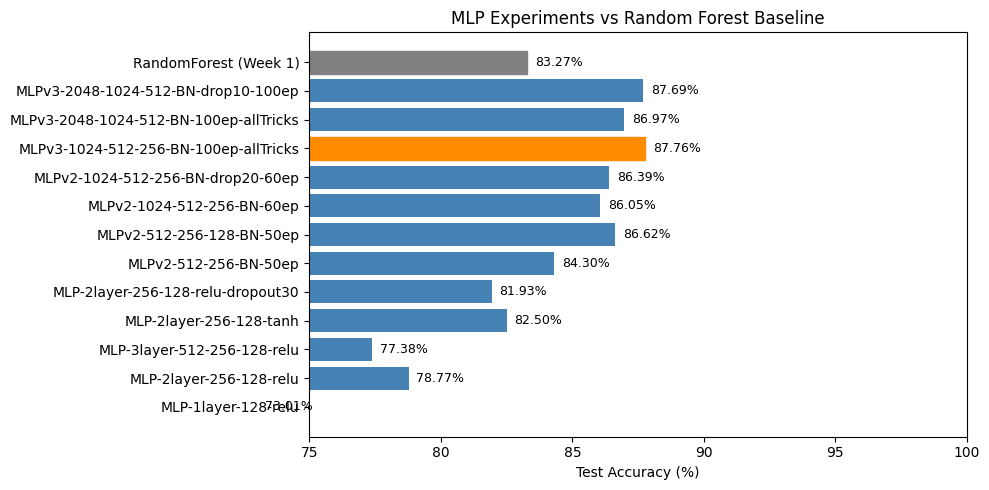

In [18]:
# Add RF to the comparison
names = [r["name"] for r in all_results] + ["RandomForest (Week 1)"]
accs = [r["best_test_acc"] * 100 for r in all_results] + [RF_ACCURACY * 100]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(names, accs, color="steelblue")

# Highlight best MLP
best_idx = accs.index(max(accs))
bars[best_idx].set_color("darkorange")
# Highlight RF in a different color
bars[-1].set_color("gray")

ax.set_xlabel("Test Accuracy (%)")
ax.set_title("MLP Experiments vs Random Forest Baseline")
ax.set_xlim(75, 100)

for i, v in enumerate(accs):
    ax.text(v + 0.3, i, f"{v:.2f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/mlp_vs_rf_comparison.png", dpi=150, bbox_inches="tight")
print("Saved comparison chart to /kaggle/working/mlp_vs_rf_comparison.png")
plt.show()

---
## 10. Save the best MLP model

We save the best model's weights so we can load it in the Streamlit app (Week 3).

In PyTorch, `model.state_dict()` contains all the learned weights. We also save the config so we know how to rebuild the model later.

In [23]:
# Find the config for the best model across ALL experiment lists (Round 1 + 2 + 3)
all_experiments = experiments + experiments_v2 + experiments_v3
best_exp = None
for exp in all_experiments:
    if exp['name'] == best_mlp['name']:
        best_exp = exp
        break

save_data = {
    "model_state_dict": best_mlp["model"].state_dict(),
    "config": {
        "hidden_sizes": best_exp["hidden_sizes"],
        "activation": best_exp["activation"],
        "dropout": best_exp["dropout"],
    },
    "best_test_accuracy": best_mlp["best_test_acc"],
    "num_classes": NUM_CLASSES,
}

torch.save(save_data, "/kaggle/working/best_mlp_model.pt")
print(f"Saved best MLP to /kaggle/working/best_mlp_model.pt")
print(f"  Architecture: {best_exp['hidden_sizes']}, {best_exp['activation']}")
print(f"  Best test accuracy: {best_mlp['best_test_acc']*100:.2f}%")
print(f"\nDownload this file from the Output tab for Week 3.")

Saved best MLP to /kaggle/working/best_mlp_model.pt
  Architecture: [1024, 512, 256], relu
  Best test accuracy: 87.76%

Download this file from the Output tab for Week 3.


---
## 11. Confusion matrix for the best MLP

Same as Week 1, but for the winning MLP. Good for comparing visually with the RF confusion matrix.

Saved MLP confusion matrix to /kaggle/working/confusion_matrix_mlp.png


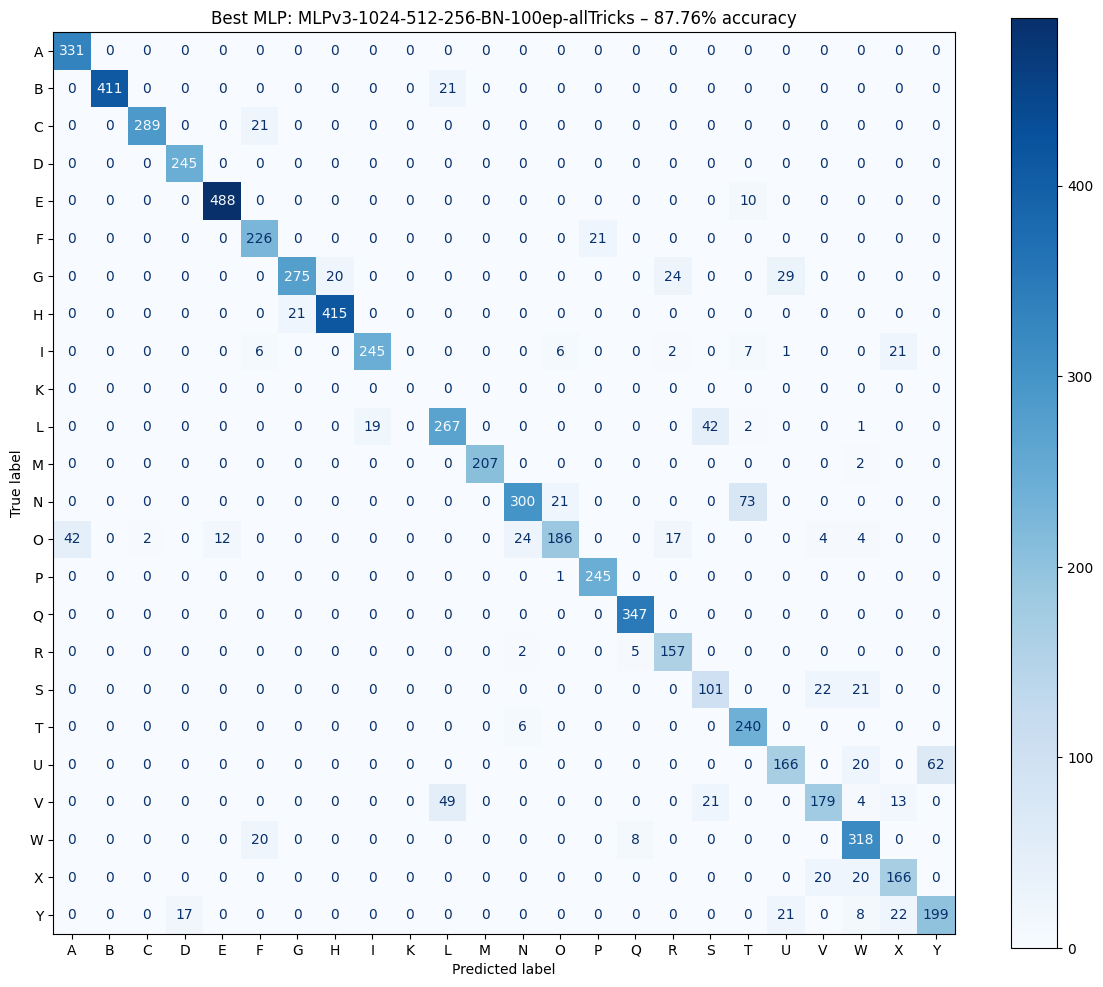


WEEK 2 COMPLETE
Best MLP: MLPv3-1024-512-256-BN-100ep-allTricks  →  87.76%
RF baseline (Week 1):           →  83.27%
Improvement: +4.49%

Download from Output tab: best_mlp_model.pt, confusion_matrix_mlp.png
Check your W&B dashboard at: wandb.ai


In [24]:
# Get predictions from the best model
best_model = best_mlp["model"].to(device)
best_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = best_model(X_batch)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_labels_np = np.array(all_labels)

cm_mlp = confusion_matrix(all_labels_np, all_preds, labels=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=LABELS)
disp.plot(ax=ax, values_format="d", cmap="Blues")
plt.title(f"Best MLP: {best_mlp['name']} – {best_mlp['best_test_acc']*100:.2f}% accuracy")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_mlp.png", dpi=150, bbox_inches="tight")
print("Saved MLP confusion matrix to /kaggle/working/confusion_matrix_mlp.png")
plt.show()

print(f"\n{'='*60}")
print(f"WEEK 2 COMPLETE")
print(f"{'='*60}")
print(f"Best MLP: {best_mlp['name']}  →  {best_mlp['best_test_acc']*100:.2f}%")
print(f"RF baseline (Week 1):           →  {RF_ACCURACY*100:.2f}%")
print(f"Improvement: +{(best_mlp['best_test_acc'] - RF_ACCURACY)*100:.2f}%")
print(f"\nDownload from Output tab: best_mlp_model.pt, confusion_matrix_mlp.png")
print(f"Check your W&B dashboard at: wandb.ai")